## BUSINESS UNDERSTANDING

The 2024 Indonesian presidential election has generated immense public discourse on social media, making these platforms a rich source of public opinion. The core problem this project addresses is the classification of public sentiment from social media text, specifically focusing on translated tweets related to Prabowo Subianto and other presidential candidates. By accurately identifying sentiment, we can gauge public reactions, track evolving opinions, and provide a clear picture of the political landscape.

From a machine learning perspective, this is framed as a binary text classification problem using supervised learning. The primary objective is to compare the performance of three specific recurrent neural network (RNN) architectures: LSTM, BiLSTM, and GRU. The business value of this project lies in providing political analysts, campaign managers, and the public with data-driven insights into opinion trends, ultimately demonstrating how deep learning can distill massive amounts of unstructured text into actionable intelligence.

=== DATA UNDERSTANDING ===
File original ditemukan: 3 file.
File labeled ditemukan : 3 file.

Total Keseluruhan Baris: 30000
Total Kolom: 4
Kolom Teks Mentah yang digunakan untuk preprocessing: 'raw_text'
Kolom Label yang digunakan: 'label'

Distribusi Label Sentimen:
label
Positive    21654
Negative     8343
Name: count, dtype: int64


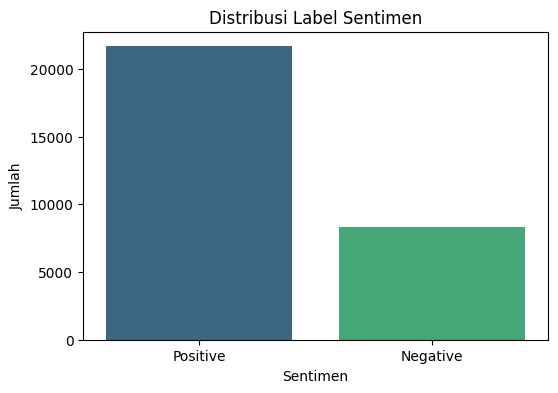


Contoh Data Mentah/Kotor Sebelum Preprocessing:


,candidate,raw_text,label
0,Anies Baswedan,info anies presiden,Positive
1,Anies Baswedan,politisi partai gerindra sandiaga uno menjawab...,Positive
2,Anies Baswedan,lanjut pak anies kita kawal sampai jadi presiden,Positive
3,Anies Baswedan,semoga allah swt menyelamatkan bangsa dan nega...,Positive
4,Anies Baswedan,chotimah kasian ya pa anies makanya sudah teka...,Positive



Contoh Kolom Teks Terjemahan dari Dataset Labeled:


,candidate,Text,label
0,Anies Baswedan,anies president info,Positive
1,Anies Baswedan,gerindra party politician sandiaga uno answers...,Positive
2,Anies Baswedan,"mr. anies continued, we will guard him until h...",Positive
3,Anies Baswedan,may allah swt save the nation and state of the...,Positive
4,Anies Baswedan,"poor chotimah, uncle anies, that's why my fami...",Positive


In [ ]:
# ==========================================
# CELL 1: DATA UNDERSTANDING & LOAD DATA MENTAH
# ==========================================
import os
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns

print("=== DATA UNDERSTANDING ===")

original_paths = sorted(glob.glob("data/original data/*.csv"))
labeled_paths = sorted(glob.glob("data/labeled data/*.csv"))

print(f"File original ditemukan: {len(original_paths)} file.")
print(f"File labeled ditemukan : {len(labeled_paths)} file.")

def read_csv_with_fallback(path):
    try:
        return pd.read_csv(path)
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding='latin1')

if len(original_paths) > 0 and len(labeled_paths) > 0:
    df_list = []

    for original_path, labeled_path in zip(original_paths, labeled_paths):
        candidate_name = os.path.splitext(os.path.basename(original_path))[0]
        df_original = read_csv_with_fallback(original_path)
        df_labeled = read_csv_with_fallback(labeled_path)

        # Mengambil panjang minimum untuk berjaga-jaga jika ada selisih jumlah baris.
        n_rows = min(len(df_original), len(df_labeled))

        df_candidate = pd.DataFrame({
            'candidate': candidate_name,
            'raw_text': df_original.loc[:n_rows - 1, 'Tweet'].reset_index(drop=True),
            'Text': df_labeled.loc[:n_rows - 1, 'Text'].reset_index(drop=True),
            'label': df_labeled.loc[:n_rows - 1, 'label'].reset_index(drop=True)
        })
        df_list.append(df_candidate)

    df = pd.concat(df_list, ignore_index=True)

    # Kolom raw_text dipakai untuk demo preprocessing; kolom label dipakai sebagai target klasifikasi.
    text_col = 'raw_text'
    label_col = 'label'

    print(f"\nTotal Keseluruhan Baris: {df.shape[0]}")
    print(f"Total Kolom: {df.shape[1]}")
    print(f"Kolom Teks Mentah yang digunakan untuk preprocessing: '{text_col}'")
    print(f"Kolom Label yang digunakan: '{label_col}'")

    print("\nDistribusi Label Sentimen:")
    distribusi = df[label_col].value_counts()
    print(distribusi)

    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=label_col, hue=label_col, palette='viridis', legend=False)
    plt.title('Distribusi Label Sentimen')
    plt.xlabel('Sentimen')
    plt.ylabel('Jumlah')
    plt.show()

    print("\nContoh Data Mentah/Kotor Sebelum Preprocessing:")
    display(df[['candidate', text_col, label_col]].head())

    print("\nContoh Kolom Teks Terjemahan dari Dataset Labeled:")
    display(df[['candidate', 'Text', label_col]].head())
else:
    print("File CSV tidak ditemukan. Pastikan direktori 'data/original data/' dan 'data/labeled data/' sudah benar.")


In [14]:
# ==========================================
# CELL 2: PREPROCESSING TEKS & LABEL
# ==========================================
import re

print("=== PREPROCESSING TEKS & LABEL ===")

def remove_url_and_non_alpha(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    return text

def case_folding(text):
    return str(text).lower()

def remove_extra_spaces(text):
    return re.sub(r'\s+', ' ', str(text)).strip()

def clean_text(text):
    text = remove_url_and_non_alpha(text)
    text = case_folding(text)
    text = remove_extra_spaces(text)
    return text

# 1. Penghapusan URL dan karakter spesial/non-alfabet
df['text_no_special'] = df[text_col].apply(remove_url_and_non_alpha)
print("\Penghapusan URL dan Karakter Spesial (Non-Alfabet)")
display(df[[text_col, 'text_no_special']].head().rename(columns={
    text_col: 'Sebelum Penghapusan Karakter Non-Alfabet & URL',
    'text_no_special': 'Sesudah Penghapusan Karakter Non-Alfabet & URL'
}))

# 2. Case folding/lowercase
df['text_lower'] = df['text_no_special'].apply(case_folding)
print("\nCase Folding (Lowercase)")
display(df[['text_no_special', 'text_lower']].head().rename(columns={
    'text_no_special': 'Sebelum Case Folding',
    'text_lower': 'Sesudah Case Folding'
}))

# 3. Penghapusan spasi berlebihan
df['cleaned_text'] = df['text_lower'].apply(remove_extra_spaces)
print("\nPenghapusan Spasi Berlebihan")
display(df[['text_lower', 'cleaned_text']].head().rename(columns={
    'text_lower': 'Sebelum',
    'cleaned_text': 'Sesudah'
}))

# 4. Filtering data dan konversi label target
df_clean = df.copy()
df_clean = df_clean.dropna(subset=[label_col, 'cleaned_text'])
df_clean = df_clean[df_clean[label_col].astype(str).str.lower().isin(['positive', 'negative'])]
df_clean = df_clean[df_clean['cleaned_text'].str.len() > 0]
df_clean['modeling_text'] = df_clean['Text'].apply(clean_text)
df_clean = df_clean[df_clean['modeling_text'].str.len() > 0]

label_mapping = {'positive': 1, 'negative': 0}
df_clean['target'] = df_clean[label_col].astype(str).str.lower().map(label_mapping)

print("\nFiltering Data dan Konversi Label")
print(f"Jumlah baris sebelum filtering: {len(df)}")
print(f"Jumlah baris setelah dibersihkan dan difilter: {len(df_clean)}")

print("\nHasil Akhir Preprocessing dari Data Kotor untuk Demo:")
display(df_clean[['candidate', 'cleaned_text', label_col, 'target']].head())

print("\nTeks yang Digunakan untuk Modeling (dataset labeled/bersih):")
display(df_clean[['modeling_text', label_col, 'target']].head())


=== PREPROCESSING TEKS & LABEL ===
\Penghapusan URL dan Karakter Spesial (Non-Alfabet)


<>:28: SyntaxWarning: invalid escape sequence '\P'
<>:28: SyntaxWarning: invalid escape sequence '\P'
C:\Users\lilol\AppData\Local\Temp\ipykernel_19668\3716924964.py:28: SyntaxWarning: invalid escape sequence '\P'
  print("\Penghapusan URL dan Karakter Spesial (Non-Alfabet)")


,Sebelum Penghapusan Karakter Non-Alfabet & URL,Sesudah Penghapusan Karakter Non-Alfabet & URL
0,info anies presiden,info anies presiden
1,politisi partai gerindra sandiaga uno menjawab...,politisi partai gerindra sandiaga uno menjawab...
2,lanjut pak anies kita kawal sampai jadi presiden,lanjut pak anies kita kawal sampai jadi presiden
3,semoga allah swt menyelamatkan bangsa dan nega...,semoga allah swt menyelamatkan bangsa dan nega...
4,chotimah kasian ya pa anies makanya sudah teka...,chotimah kasian ya pa anies makanya sudah teka...



Case Folding (Lowercase)


,Sebelum Case Folding,Sesudah Case Folding
0,info anies presiden,info anies presiden
1,politisi partai gerindra sandiaga uno menjawab...,politisi partai gerindra sandiaga uno menjawab...
2,lanjut pak anies kita kawal sampai jadi presiden,lanjut pak anies kita kawal sampai jadi presiden
3,semoga allah swt menyelamatkan bangsa dan nega...,semoga allah swt menyelamatkan bangsa dan nega...
4,chotimah kasian ya pa anies makanya sudah teka...,chotimah kasian ya pa anies makanya sudah teka...


...

,Sebelum,Sesudah
0,info anies presiden,info anies presiden
1,politisi partai gerindra sandiaga uno menjawab...,politisi partai gerindra sandiaga uno menjawab...
2,lanjut pak anies kita kawal sampai jadi presiden,lanjut pak anies kita kawal sampai jadi presiden
3,semoga allah swt menyelamatkan bangsa dan nega...,semoga allah swt menyelamatkan bangsa dan nega...
4,chotimah kasian ya pa anies makanya sudah teka...,chotimah kasian ya pa anies makanya sudah teka...



Filtering Data dan Konversi Label
Jumlah baris sebelum filtering: 30000
Jumlah baris setelah dibersihkan dan difilter: 29997

Hasil Akhir Preprocessing dari Data Kotor untuk Demo:


,candidate,cleaned_text,label,target
0,Anies Baswedan,info anies presiden,Positive,1
1,Anies Baswedan,politisi partai gerindra sandiaga uno menjawab...,Positive,1
2,Anies Baswedan,lanjut pak anies kita kawal sampai jadi presiden,Positive,1
3,Anies Baswedan,semoga allah swt menyelamatkan bangsa dan nega...,Positive,1
4,Anies Baswedan,chotimah kasian ya pa anies makanya sudah teka...,Positive,1



Teks yang Digunakan untuk Modeling (dataset labeled/bersih):


,modeling_text,label,target
0,anies president info,Positive,1
1,gerindra party politician sandiaga uno answers...,Positive,1
2,mr anies continued we will guard him until he ...,Positive,1
3,may allah swt save the nation and state of the...,Positive,1
4,poor chotimah uncle anies that s why my family...,Positive,1


In [15]:
# ==========================================
# CELL 3: SPLIT DATA
# ==========================================
from sklearn.model_selection import train_test_split

print("=== SPLIT DATA (TRAIN, VAL, TEST) ===")

# Pertama, pisahkan 80% untuk (Train+Val) dan 20% untuk Test
X_temp, X_test, y_temp, y_test = train_test_split(
    df_clean['modeling_text'], 
    df_clean['target'], 
    test_size=0.2, 
    random_state=42, 
    stratify=df_clean['target']
)

# Kedua, pisahkan sisa 80% tadi menjadi 60% Train dan 20% Validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, 
    y_temp, 
    test_size=0.25, 
    random_state=42, 
    stratify=y_temp
)

print(f"Data Train: {len(X_train)} baris")
print(f"Data Validation: {len(X_val)} baris")
print(f"Data Test: {len(X_test)} baris")


=== SPLIT DATA (TRAIN, VAL, TEST) ===
Data Train: 17997 baris
Data Validation: 6000 baris
Data Test: 6000 baris


In [16]:
# ==========================================
# CELL 4: TOKENIZATION & PADDING
# ==========================================
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("=== TOKENIZATION & PADDING ===")

# Parameter
vocab_size = 5000       
max_length = 100        
oov_tok = "<OOV>"       

# 1. Inisiasi dan Fit Tokenizer pada data Train
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(X_train)

# 2. Mengubah teks menjadi sequences (urutan angka)
train_sequences = tokenizer.texts_to_sequences(X_train)
val_sequences = tokenizer.texts_to_sequences(X_val)
test_sequences = tokenizer.texts_to_sequences(X_test)

# 3. Menyamakan panjang (Padding)
X_train_pad = pad_sequences(train_sequences, maxlen=max_length, padding='post', truncating='post')
X_val_pad = pad_sequences(val_sequences, maxlen=max_length, padding='post', truncating='post')
X_test_pad = pad_sequences(test_sequences, maxlen=max_length, padding='post', truncating='post')

print("Proses Tokenisasi dan Padding Selesai.")
print(f"Bentuk X_train_pad: {X_train_pad.shape}")
print(f"Bentuk X_val_pad  : {X_val_pad.shape}")
print(f"Bentuk X_test_pad : {X_test_pad.shape}")


=== TOKENIZATION & PADDING ===
Proses Tokenisasi dan Padding Selesai.
Bentuk X_train_pad: (17997, 100)
Bentuk X_val_pad  : (6000, 100)
Bentuk X_test_pad : (6000, 100)


In [17]:
# ==========================================
# CELL 5: SETUP MODEL & CALLBACKS
# ==========================================
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import time

print("=== PERSIAPAN MODELING ===")

# Parameter arsitektur Neural Network
embedding_dim = 128
epochs = 5
batch_size = 64

# Callback: Hentikan training jika val_loss tidak membaik dalam 2 epoch
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Tempat menyimpan history training untuk visualisasi nanti
training_histories = {}


=== PERSIAPAN MODELING ===


In [18]:
# ==========================================
# CELL 6: MODEL LSTM
# ==========================================
print("=== MELATIH MODEL LSTM ===")
model_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),
    LSTM(64),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid') # sigmoid untuk binary classification (0 atau 1)
])

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_lstm.summary()

start_time = time.time()
training_histories['LSTM'] = model_lstm.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop]
)
print(f"Waktu Pelatihan LSTM: {time.time() - start_time:.2f} detik")


=== MELATIH MODEL LSTM ===


c:\laragon\www\NLP Version 2\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 20s 59ms/step - accuracy: 0.7217 - loss: 0.6043 - val_accuracy: 0.7218 - val_loss: 0.5929
Epoch 2/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 15s 54ms/step - accuracy: 0.7219 - loss: 0.5965 - val_accuracy: 0.7218 - val_loss: 0.5937
Epoch 3/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - accuracy: 0.7219 - loss: 0.5966 - val_accuracy: 0.7218 - val_loss: 0.5920
Epoch 4/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step - accuracy: 0.7219 - loss: 0.5953 - val_accuracy: 0.7218 - val_loss: 0.5913
Epoch 5/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step - accuracy: 0.7219 - loss: 0.5944 - val_accuracy: 0.7218 - val_loss: 0.5913
Waktu Pelatihan LSTM: 78.62 detik


In [19]:
# ==========================================
# CELL 7: MODEL BiLSTM
# ==========================================
print("\n=== MELATIH MODEL BiLSTM ===")
model_bilstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_bilstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_bilstm.summary()

start_time = time.time()
training_histories['BiLSTM'] = model_bilstm.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop]
)
print(f"Waktu Pelatihan BiLSTM: {time.time() - start_time:.2f} detik")



=== MELATIH MODEL BiLSTM ===


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 40s 91ms/step - accuracy: 0.8160 - loss: 0.4199 - val_accuracy: 0.8787 - val_loss: 0.2987
Epoch 2/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 23s 83ms/step - accuracy: 0.9097 - loss: 0.2487 - val_accuracy: 0.8958 - val_loss: 0.2613
Epoch 3/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 19s 69ms/step - accuracy: 0.9352 - loss: 0.1851 - val_accuracy: 0.8967 - val_loss: 0.3014
Epoch 4/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 21s 74ms/step - accuracy: 0.9506 - loss: 0.1431 - val_accuracy: 0.8972 - val_loss: 0.3447
Waktu Pelatihan BiLSTM: 103.97 detik


In [20]:
# ==========================================
# CELL 8: MODEL GRU
# ==========================================
print("\n=== MELATIH MODEL GRU ===")
model_gru = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),
    GRU(64),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_gru.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_gru.summary()

start_time = time.time()
training_histories['GRU'] = model_gru.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stop]
)
print(f"Waktu Pelatihan GRU: {time.time() - start_time:.2f} detik")



=== MELATIH MODEL GRU ===


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 18s 55ms/step - accuracy: 0.7181 - loss: 0.6059 - val_accuracy: 0.7218 - val_loss: 0.5913
Epoch 2/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.7219 - loss: 0.6004 - val_accuracy: 0.7218 - val_loss: 0.5915
Waktu Pelatihan GRU: 31.49 detik


In [21]:
# ==========================================
# CELL 9: EVALUASI MODEL
# ==========================================
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

print("=== EVALUASI PADA DATA TEST ===")

models = {
    'LSTM': model_lstm,
    'BiLSTM': model_bilstm,
    'GRU': model_gru
}

predictions = {}

for name, model in models.items():
    print(f"\n--- Evaluasi Model {name} ---")
    
    # Memprediksi probabilitas
    y_pred_probs = model.predict(X_test_pad)
    # Mengubah probabilitas menjadi kelas 0 atau 1
    y_pred = (y_pred_probs > 0.5).astype(int)
    predictions[name] = y_pred
    
    # Menghitung Metrik
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    
    # Menampilkan Classification Report lengkap (Precision, Recall, F1-Score)
    print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))


=== EVALUASI PADA DATA TEST ===

--- Evaluasi Model LSTM ---
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step
Accuracy: 0.7218
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00      1669
    Positive       0.72      1.00      0.84      4331

    accuracy                           0.72      6000
   macro avg       0.36      0.50      0.42      6000
weighted avg       0.52      0.72      0.61      6000


--- Evaluasi Model BiLSTM ---


c:\laragon\www\NLP Version 2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\laragon\www\NLP Version 2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\laragon\www\NLP Version 2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step
Accuracy: 0.8942
              precision    recall  f1-score   support

    Negative       0.81      0.81      0.81      1669
    Positive       0.93      0.92      0.93      4331

    accuracy                           0.89      6000
   macro avg       0.87      0.87      0.87      6000
weighted avg       0.89      0.89      0.89      6000


--- Evaluasi Model GRU ---
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
Accuracy: 0.7218
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00      1669
    Positive       0.72      1.00      0.84      4331

    accuracy                           0.72      6000
   macro avg       0.36      0.50      0.42      6000
weighted avg       0.52      0.72      0.61      6000



c:\laragon\www\NLP Version 2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\laragon\www\NLP Version 2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\laragon\www\NLP Version 2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

=== VISUALISASI TRAINING & CONFUSION MATRIX ===


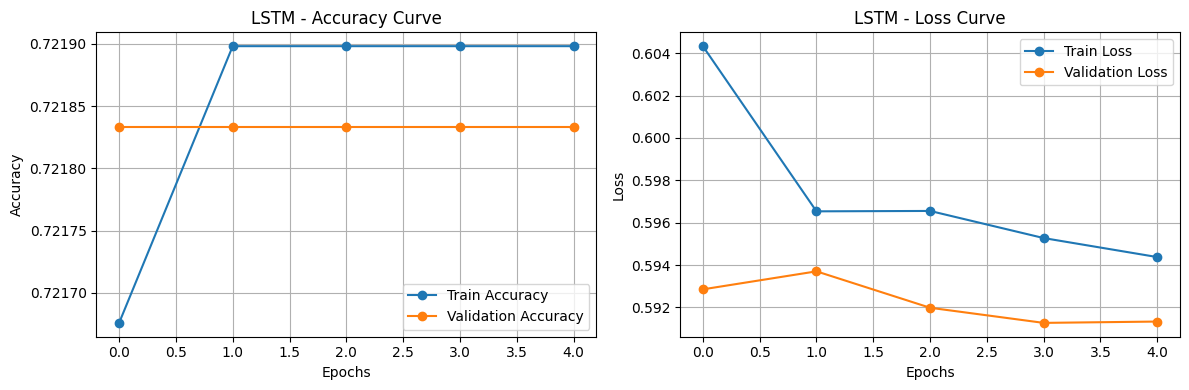

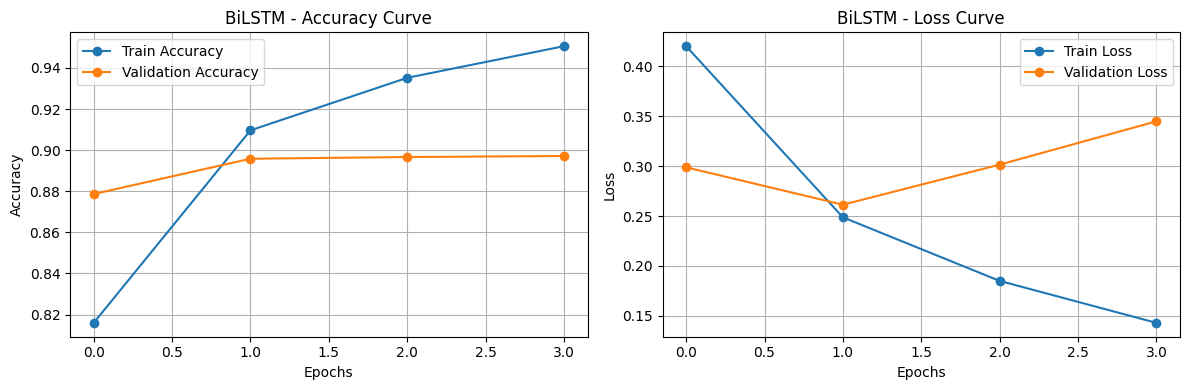

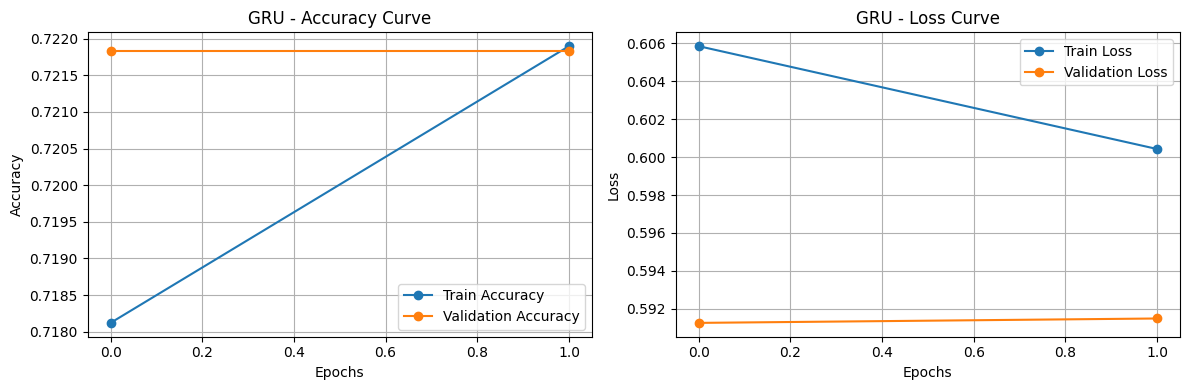

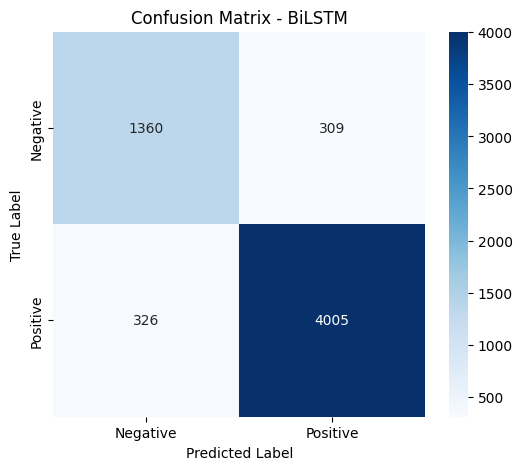

In [22]:
# ==========================================
# CELL 10: VISUALISASI HASIL PELATIHAN
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

print("=== VISUALISASI TRAINING & CONFUSION MATRIX ===")

# 1. Grafik Accuracy dan Loss dari Proses Training
def plot_history(history, model_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Accuracy Plot
    ax1.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
    ax1.set_title(f'{model_name} - Accuracy Curve')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)
    
    # Loss Plot
    ax2.plot(history.history['loss'], label='Train Loss', marker='o')
    ax2.plot(history.history['val_loss'], label='Validation Loss', marker='o')
    ax2.set_title(f'{model_name} - Loss Curve')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

# Menampilkan grafik untuk tiap model
for name, history in training_histories.items():
    plot_history(history, name)

# 2. Confusion Matrix Heatmap (Mengambil model BiLSTM sebagai contoh terbaik)
best_model_name = 'BiLSTM'
cm = confusion_matrix(y_test, predictions[best_model_name])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'], 
            yticklabels=['Negative', 'Positive'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()
